In [1]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/project.zip" -d "/content/project"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/project.zip
   creating: /content/project/project/
  inflating: /content/project/project/all_math_with_context.csv  
   creating: /content/project/project/data/
  inflating: /content/project/project/data/all_math_with_context.csv  
  inflating: /content/project/project/data/math_ground_truth.csv  
  inflating: /content/project/project/data/math_mutants_detail.csv  
  inflating: /content/project/project/data/pilot_ground_truth.csv  
  inflating: /content/project/project/data/pilot_ground_truth_math.csv  
  inflating: /content/project/project/full_ground_truth.csv  
 extracting: /content/project/project/Mutant_ranking_project.zip  
   creating: /content/project/project/Mutant_ranking_project_unzipped/
   creating: /content/project/project/Mutant_ranking_project_unzipped/data/
  inflating: /content/project/project/Mutant_ranking_project_unzipped/data/all_math_with_context.csv  
  inflating: /content/project/project/Mutant_ranking_

Tổng số mutants đã tải: 20957

========== RQ1: THỐNG KÊ MAS ==========
         mas_llm  mas_random
count  34.000000   34.000000
mean    0.997907    0.999686
std     0.060846    0.039133
min     0.779221    0.926877
25%     0.981336    0.989513
50%     0.997816    0.999624
75%     1.022518    1.009352
max     1.151111    1.168831

[*] Wilcoxon Signed-Rank Test (H1: LLM > Random): p-value = 0.2652200456248746
[*] Cliff's Delta (Effect Size): 0.029411764705882353


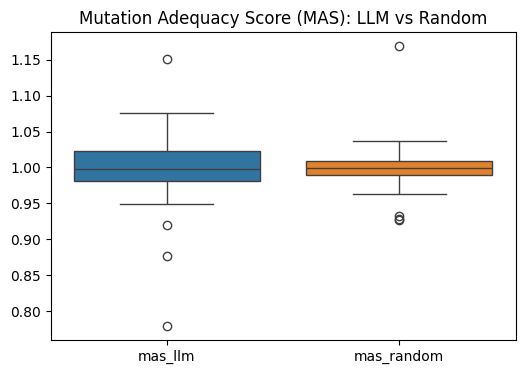


========== RQ2: PHÂN PHỐI OPERATOR CATEGORY ==========
[*] Chi-Square Test: p-value = 9.61066306073109e-189
[*] Cramér's V (Effect Size): 0.1730735576785786


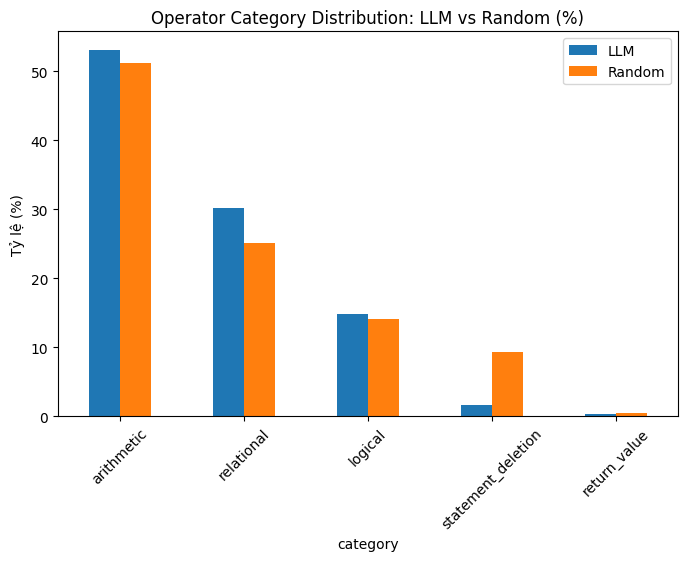

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trỏ đường dẫn vào thư mục chứa code và dữ liệu
os.chdir('/content/project/project')
sys.path.append('./scripts')
from compute_metric import compute_mas, compute_err, get_top_n_percent_mutants, get_random_mutants

# 2. Tải toàn bộ dữ liệu Pilot (Math, Chart, Time, Lang)
data_paths = [
    './pilot_llm_output.csv',
    './qwen-time-chart-pilot_unzipped/qwen-math-run/results/chart_pilot_llm_output.csv',
    './qwen-time-chart-pilot_unzipped/qwen-math-run/results/time_pilot_llm_output.csv',
    './Mutant_ranking_project_unzipped/qwen-math-run/results/math_pilot_llm_output.csv'
]

dfs = []
for p in data_paths:
    if os.path.exists(p): dfs.append(pd.read_csv(p))

if not dfs:
    print("Không tìm thấy dữ liệu!")
else:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Tổng số mutants đã tải: {len(df_all)}")

    # ----------------------------------------------------
    # RQ1: Phân tích MAS & Wilcoxon Test
    # ----------------------------------------------------
    results = []
    bugs = df_all.groupby(['project', 'bug_id'])
    for (proj, bug_id), df_bug in bugs:
        if len(df_bug) == 0: continue
        mas_llm = compute_mas(get_top_n_percent_mutants(df_bug), df_bug)
        mas_rand = compute_mas(get_random_mutants(df_bug), df_bug)
        results.append({'project': proj, 'bug_id': bug_id, 'mas_llm': mas_llm, 'mas_random': mas_rand})

    df_res = pd.DataFrame(results)
    print("\n========== RQ1: THỐNG KÊ MAS ==========")
    print(df_res[['mas_llm', 'mas_random']].describe())

    stat, p_val = stats.wilcoxon(df_res['mas_llm'], df_res['mas_random'], alternative='greater')
    print(f"\n[*] Wilcoxon Signed-Rank Test (H1: LLM > Random): p-value = {p_val}")

    def cliffs_delta(lst1, lst2):
        m, n = len(lst1), len(lst2)
        if m==0 or n==0: return 0
        dom = sum(1 for x in lst1 for y in lst2 if x > y) - sum(1 for x in lst1 for y in lst2 if x < y)
        return dom / (m * n)
    print(f"[*] Cliff's Delta (Effect Size): {cliffs_delta(df_res['mas_llm'].tolist(), df_res['mas_random'].tolist())}")

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_res[['mas_llm', 'mas_random']])
    plt.title("Mutation Adequacy Score (MAS): LLM vs Random")
    plt.show()

    # ----------------------------------------------------
    # RQ2: Phân tích Operator Category & Chi-square
    # ----------------------------------------------------
    llm_sel = pd.concat([get_top_n_percent_mutants(d) for _, d in bugs if len(d)>0])
    rand_sel = pd.concat([get_random_mutants(d) for _, d in bugs if len(d)>0])

    df_cat = pd.DataFrame({
        'LLM': llm_sel['category'].value_counts(),
        'Random': rand_sel['category'].value_counts()
    }).fillna(0)

    print("\n========== RQ2: PHÂN PHỐI OPERATOR CATEGORY ==========")
    chi2, p_cat, dof, ex = stats.chi2_contingency(df_cat.T)
    print(f"[*] Chi-Square Test: p-value = {p_cat}")

    n_obs = df_cat.sum().sum()
    min_dim = min(df_cat.shape) - 1
    cramer_v = np.sqrt(chi2 / (n_obs * max(1, min_dim)))
    print(f"[*] Cramér's V (Effect Size): {cramer_v}")

    df_cat_pct = df_cat.div(df_cat.sum(axis=0), axis=1) * 100
    df_cat_pct.plot(kind='bar', figsize=(8, 5))
    plt.title("Operator Category Distribution: LLM vs Random (%)")
    plt.ylabel("Tỷ lệ (%)")
    plt.xticks(rotation=45)
    plt.show()